In [1]:
import os
import uproot
import scienceplots
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
from pathlib import Path
from typing import Dict, List, Optional
from GeoModelSplitCal_Extraction_Classes import SimFileReader, ProcessHits
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

Integrated energy = [110.7796175  108.50861488 112.61319801 ... 118.42296394 115.47659161
 204.56757637]
Fraction of original energy = [0.01107796 0.01085086 0.01126132 ... 0.0118423  0.01154766 0.02045676]


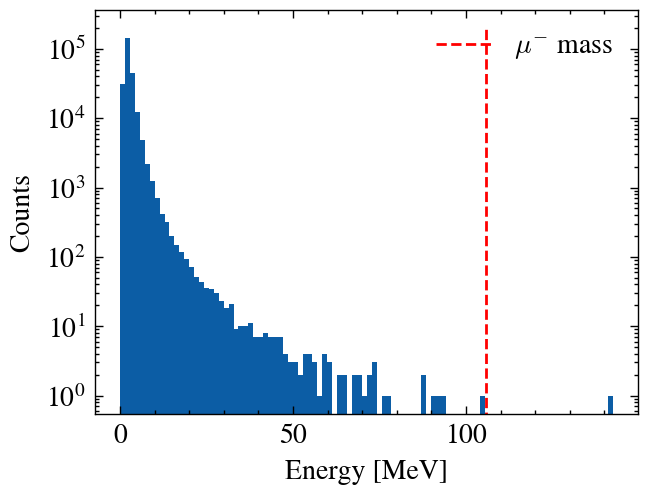

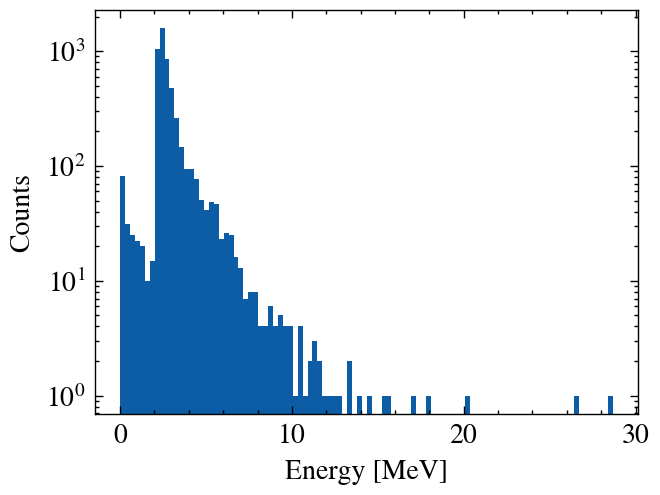

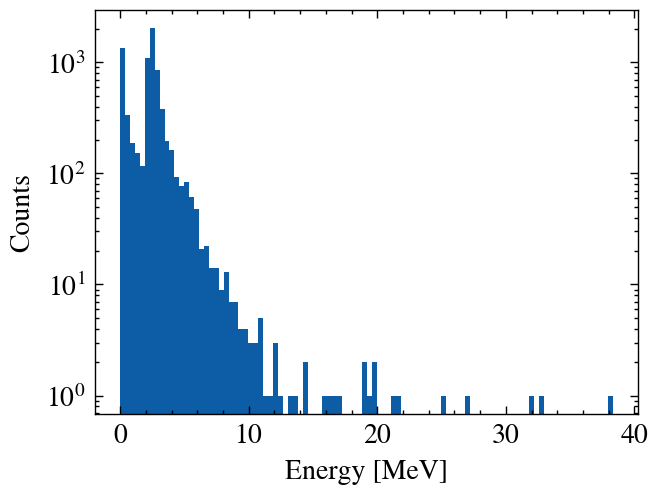

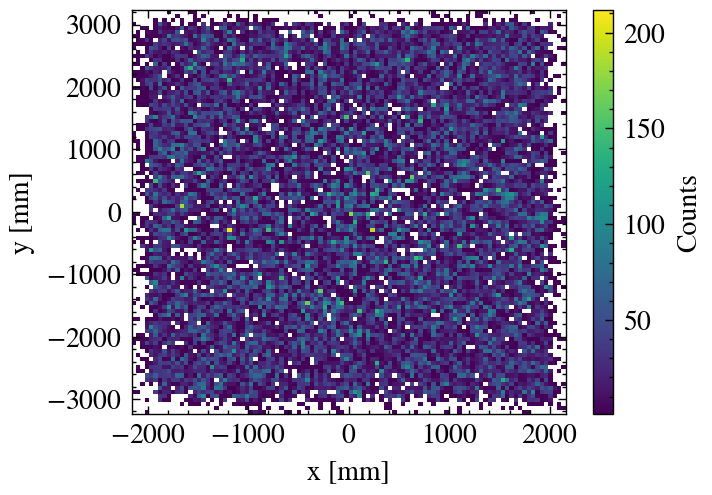

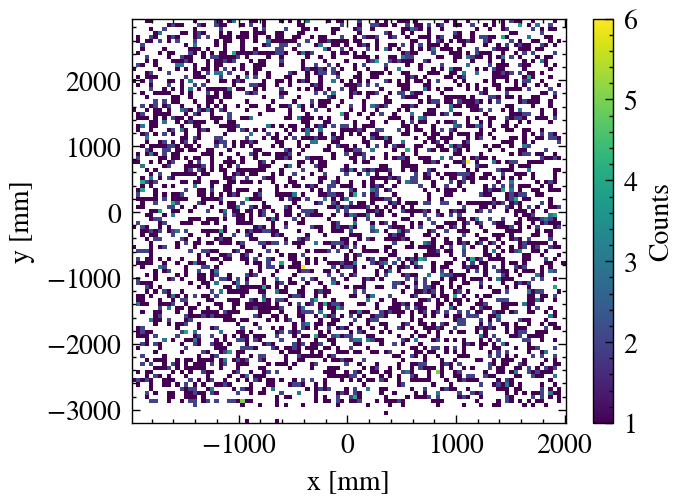

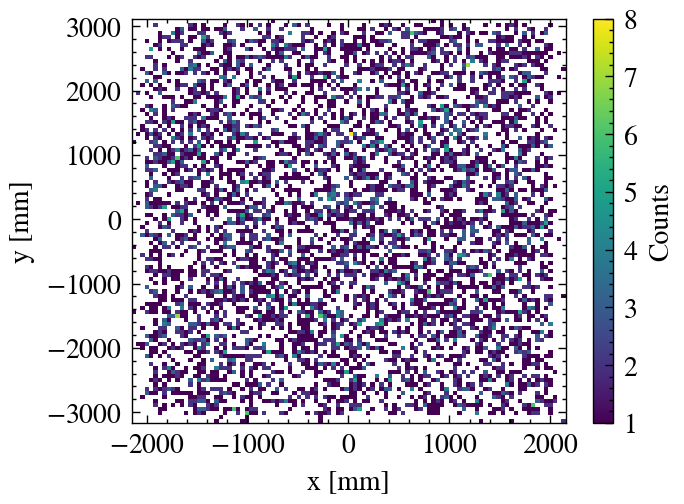

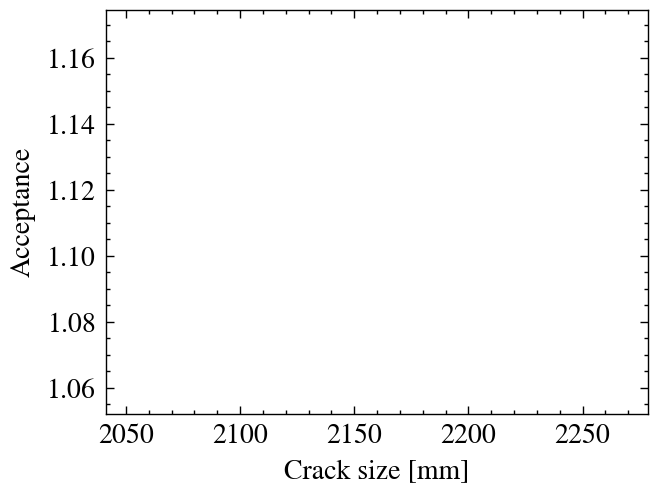

In [2]:

def main_exec():
    file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_Cracks_Gaussian"
    Sim = SimFileReader(os.path.join(file_path, "sim_mu-_10000MeV_2160mm.root"))

    branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
    edeps, x_globals, y_globals, z_globals, x_local, y_local, z_local, types = Sim.get_branches(branches)
    # print(f"Branches extracted: {branches}")
    # print(f"Number of events: {len(edeps)}")
    #print(f"Number of hits in first event: {len(edeps[1])}")
    # print(f"First event energy deposits: {edeps[1]}")
    # print(f"First event x hits: {x_globals[1]}")
    # print(f"First event y hits: {y_globals[1]}")
    # print(f"First event z hits: {z_globals[1]}")
    # print(f"First event layer types: {types[1]}")
    # print(f"Number of events after masking: {len(x_globals)}")
    # print(f"Number of events after masking: {len(x_globals[:][types == 1])}")
    # print(f"x hits in first layer across all events: {x_globals[:][types == 1]}")
    # zero_edeps = edeps[edeps == 0]
    # print(f"Zero energy points: {zero_edeps}")

    Sim.Diagnostic_Plotting(file_path)

if __name__ == "__main__":
    main_exec()


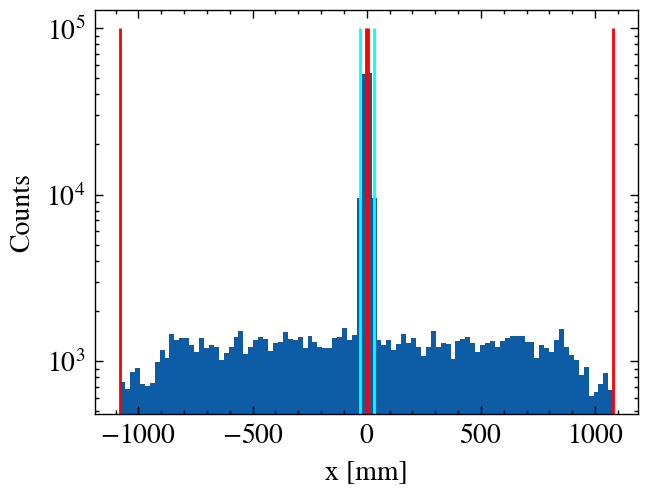

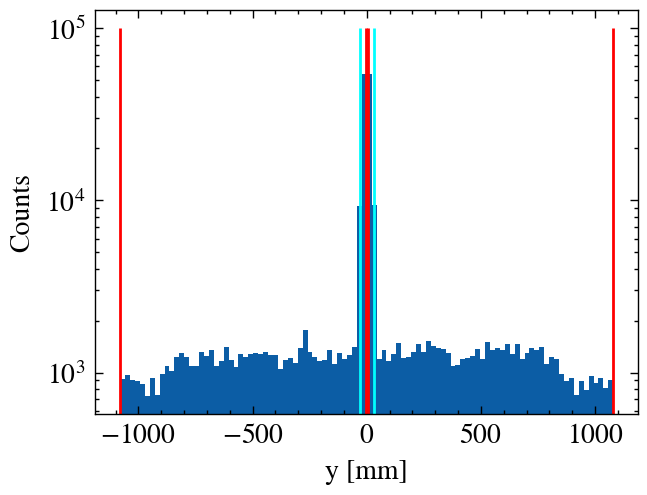

In [3]:
file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_Cracks_Gaussian"
Sim = SimFileReader(os.path.join(file_path, "sim_mu-_10000MeV_2160mm.root"))

branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

#x and y local coordinates
with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(ak.flatten(x_locals), bins = 100)
    plt.vlines(x=[-1080, 1080], ymin=0, ymax=100000, colors='red')
    plt.vlines(x=[-30, 30], ymin=0, ymax=100000, colors='cyan')
    plt.vlines(x=[-5, 5], ymin=0, ymax=100000, colors='red')
    plt.xlabel("x [mm]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(ak.flatten(y_locals), bins = 100)
    plt.vlines(x=[-1080, 1080], ymin=0, ymax=100000, colors='red')
    plt.vlines(x=[-30, 30], ymin=0, ymax=100000, colors='cyan')
    plt.vlines(x=[-5, 5], ymin=0, ymax=100000, colors='red')
    plt.xlabel("y [mm]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

100
101
[1]
[1.93]
[1.93]


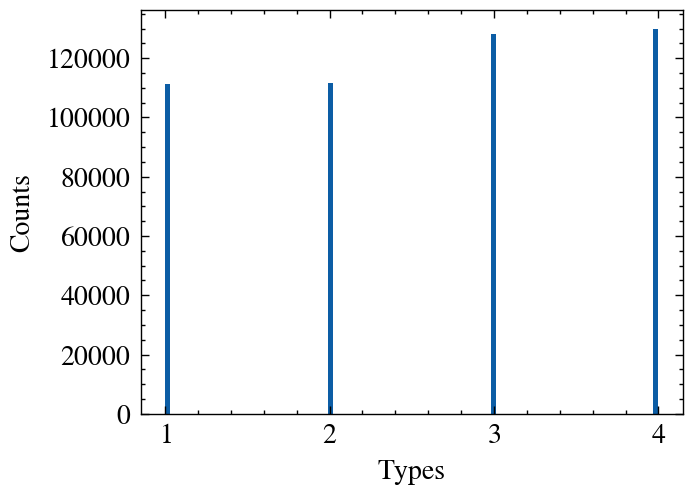

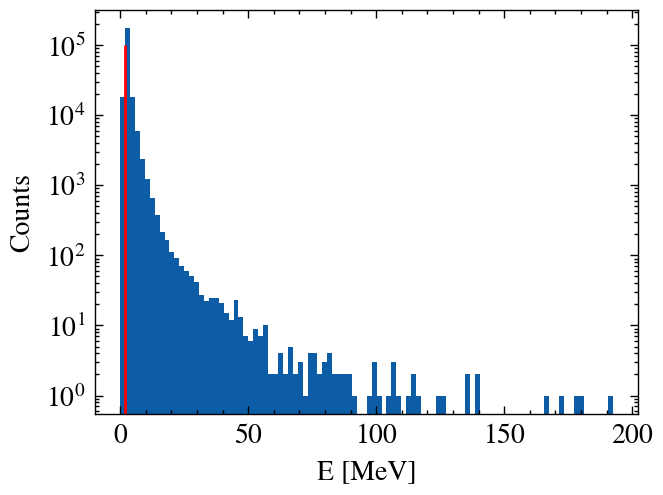

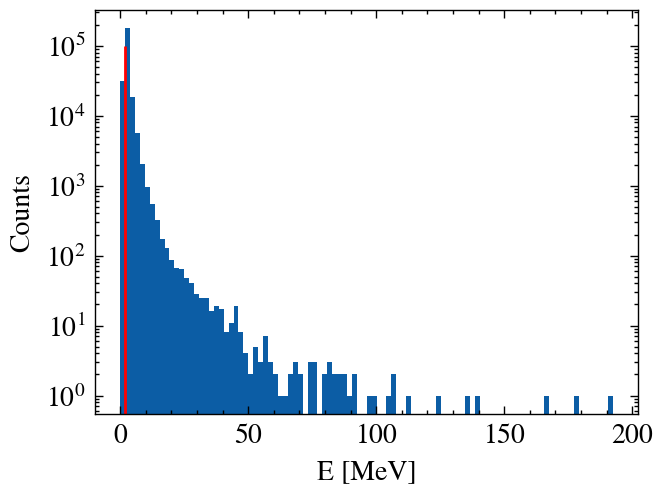

In [4]:
# MIP calibration

file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_MIP_Calibration"
Sim = SimFileReader(os.path.join(file_path, "sim_mu-_10000MeV_1000mm.root"))
branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

edeps = ak.flatten(edeps)
types = ak.flatten(types)

edep_wide = edeps[(types == 1) | (types == 2)]

edep_thin = edeps[(types == 2) | (types == 3)]

wide_hist, wide_edge = np.histogram(edep_wide, bins=100)
thin_hist, thin_edge = np.histogram(edep_thin, bins=100)

print(len(thin_hist))
print(len(thin_edge))

peak_indices_wide, _ = find_peaks(wide_hist, height=10**5)
peak_indices_thin, _ = find_peaks(thin_hist, height=10**5)

print(peak_indices_thin)

edep_peak_wide = (wide_edge[peak_indices_wide + 1] + wide_edge[peak_indices_wide-1])/2
edep_peak_thin = (thin_edge[peak_indices_thin + 1] + thin_edge[peak_indices_thin-1])/2

print(edep_peak_wide)
print(edep_peak_thin)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(types, bins = 100)
    plt.xlabel("Types")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_wide, bins = 100)
    plt.vlines(edep_peak_wide, ymin=0, ymax=100000, colors='red')
    plt.xlabel("E [MeV]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_thin, bins = 100)
    plt.vlines(edep_peak_thin, ymin=0, ymax=100000, colors='red')
    plt.xlabel("E [MeV]")
    plt.ylabel("Counts")
    plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

In [5]:
def fractional_energy_resolution_fit(E, a, c):
    return np.sqrt(a**2/E + c**2)

def resolution_fit_error(E, a, c, cov_matrix):
    """
    Calculate propagated errors for risetime derived from radii.

    Parameters:
        E (array-like): Measured E.
        a, c (float): Fit parameters.
        cov_matrix (2D array): Covariance matrix for the fit parameters [a, c].

    Returns:
        tuple: frac_res propagated uncertainties.
    """
    errors = []
    for Ei in E:
        d_y_da = a/(Ei*np.sqrt((a**2/Ei) + c**2))
        d_y_dc = c/np.sqrt((a**2/Ei) + c**2)

        # Gradient vector
        gradient = np.array([d_y_da, d_y_dc])
        
        # Propagated variance
        sigma_y_squared = gradient @ cov_matrix @ gradient.T
        sigma_y = np.sqrt(sigma_y_squared)
        errors.append(sigma_y)
        
    return np.array(errors)

[0.03255433 0.02266932 0.0193781  0.01580955 0.00972706]


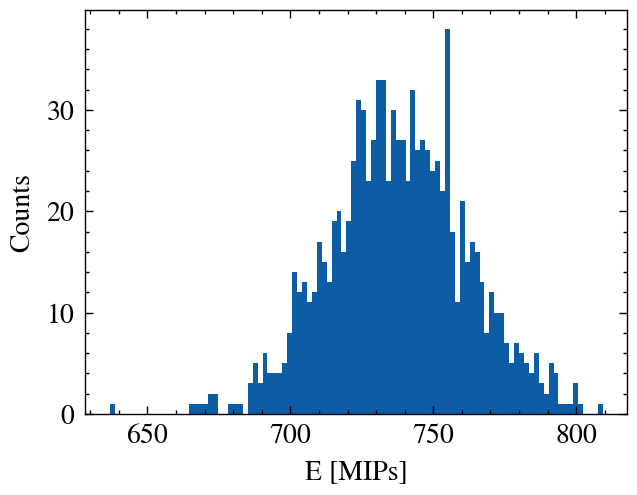

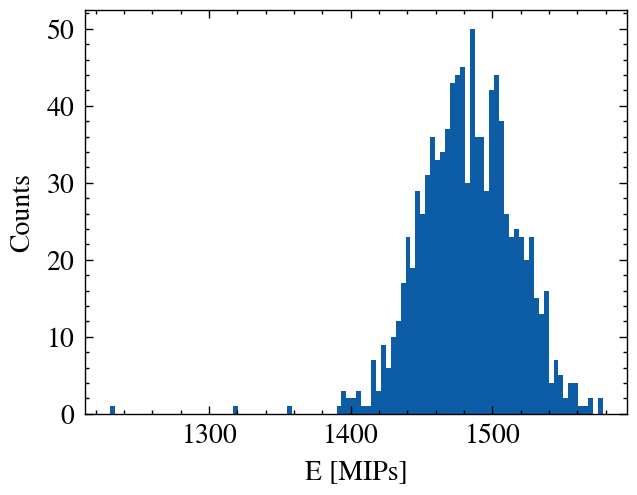

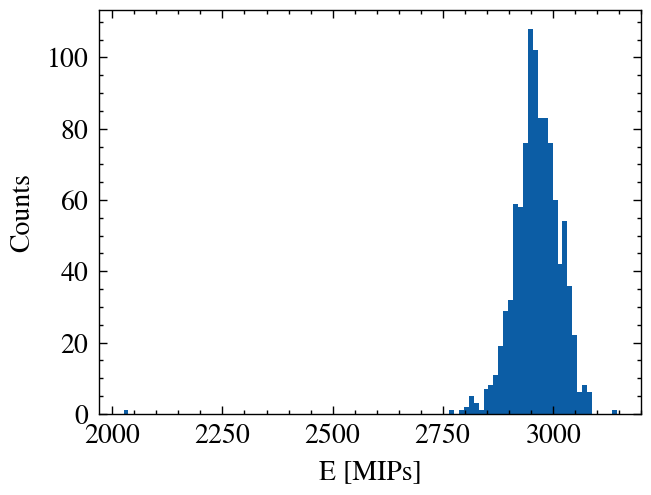

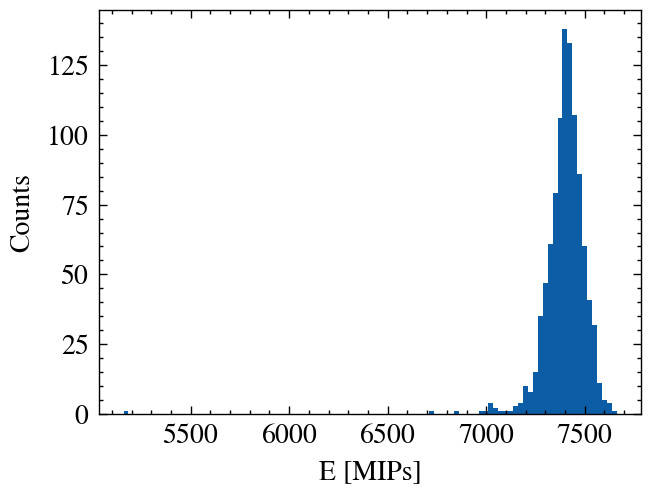

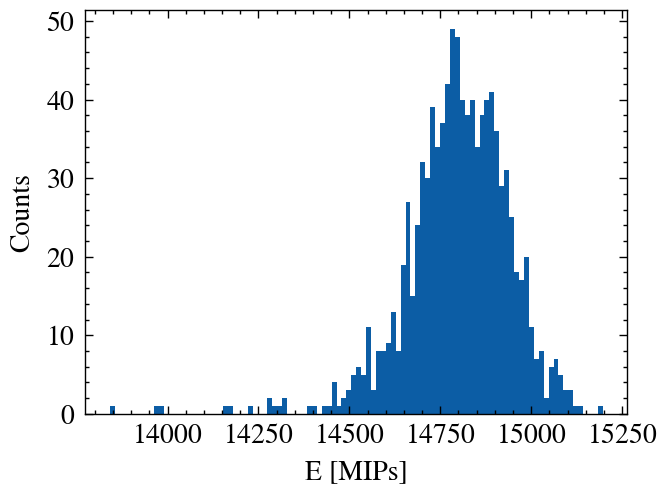

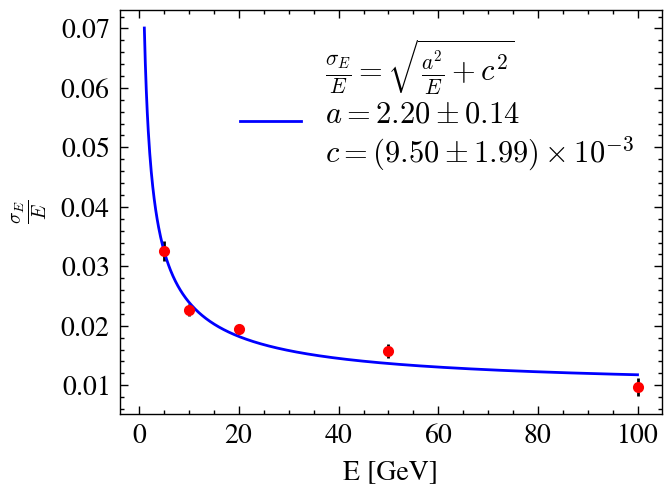

In [17]:
# Fractional resolution for 3 mm Pb

energies = np.array([5_000, 10_000, 20_000, 50_000, 100_000])

edep_sum_array = []

file_path =  r"C:\Users\ewrightl\cernbox\EPWL_ECAL_Simulations\sim_runs\run_ECAL_Resolution"

for energy in energies:
    Sim = SimFileReader(os.path.join(file_path, f"sim_mu-_{energy}MeV_1000mm.root"))
    branches = ["edep", "x_global", "y_global", "z_global", "x_local", "y_local", "z_local", "type"]
    edeps, x_globals, y_globals, z_globals, x_locals, y_locals, z_locals, types = Sim.get_branches(branches)

    edep_sum = [np.sum(edeps[i]) for i in range(len(edeps))]

    edep_sum_array.append(edep_sum)

edep_sum_array = np.array(edep_sum_array)

frac_resolutions = np.array([np.std(edep_sum_array[i])/np.mean(edep_sum_array[i]) for i in range(5)])

#print(edep_sum_array)
print(frac_resolutions)

popt, pcov = curve_fit(fractional_energy_resolution_fit, energies, frac_resolutions)

a, c = popt

unc_params = np.sqrt(np.diag(pcov))

fitted_energies = np.linspace(10**3, 10**5, num=10**3)

fitted_frac_resolutions = fractional_energy_resolution_fit(fitted_energies, a, c)

frac_error = resolution_fit_error(energies, a, c, pcov)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[0]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[1]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()


with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[2]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[3]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()


with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.hist(edep_sum_array[4]/1.93, bins = 100)
    plt.xlabel("E [MIPs]")
    plt.ylabel("Counts")
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()


legend_text = (
    r"$\frac{\sigma_E}{E} = \sqrt{\frac{a^2}{E} + c^2}$" "\n"
    rf"$a = {a:.2f} \pm {unc_params[0]:.2f}$" "\n"
    rf"$c = ({10**3*c:.2f} \pm {10**3*unc_params[1]:.2f})\times 10^{{-3}}$" "\n"
)

with plt.style.context(['science', 'no-latex']):
    plt.rcParams['figure.dpi'] = 200
    plt.errorbar(energies/10**3,frac_resolutions, yerr=frac_error, fmt='.', color='red', ecolor='black')
    plt.plot(fitted_energies/10**3, fitted_frac_resolutions, color='blue')
    plt.xlabel("E [GeV]")
    plt.ylabel(r"$\frac{\sigma_E}{E}$")
    plt.legend([legend_text], loc="best", prop={"family": "serif", "size": 11})
    #plt.yscale("log")
    #plt.savefig(os.path.join(plotting_directory, "SplitCalGap_first_layer_energy.png"))
    plt.show()